In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples



In [3]:
# Loading scaled features
df = pd.read_csv("data/claims_train_scaled.csv")
df.drop(columns=["Area","VehBrand","VehGas","Region","ClaimNb", "Exposure"],inplace=True)


In [ ]:
import matplotlib.pyplot as plt
# Trying on 1-20 clusters
inertiaList = []
K = range(1, 20)
for j in K:
    clusters = KMeans(n_clusters=j).fit(df)
    print(f"for n clusters = ", j, " The inertia is: ", clusters.inertia_)
    inertiaList.append(clusters.inertia_)



KeyboardInterrupt: 

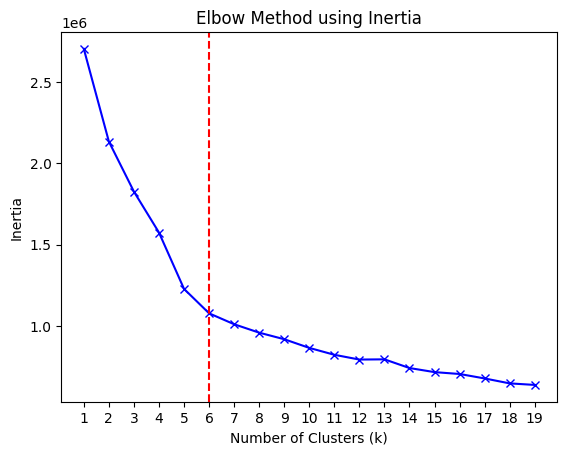

In [ ]:
plt.plot(K, inertiaList, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.axvline(x=6, color="red", linestyle='--')
plt.title('Elbow Method using Inertia')
plt.show()

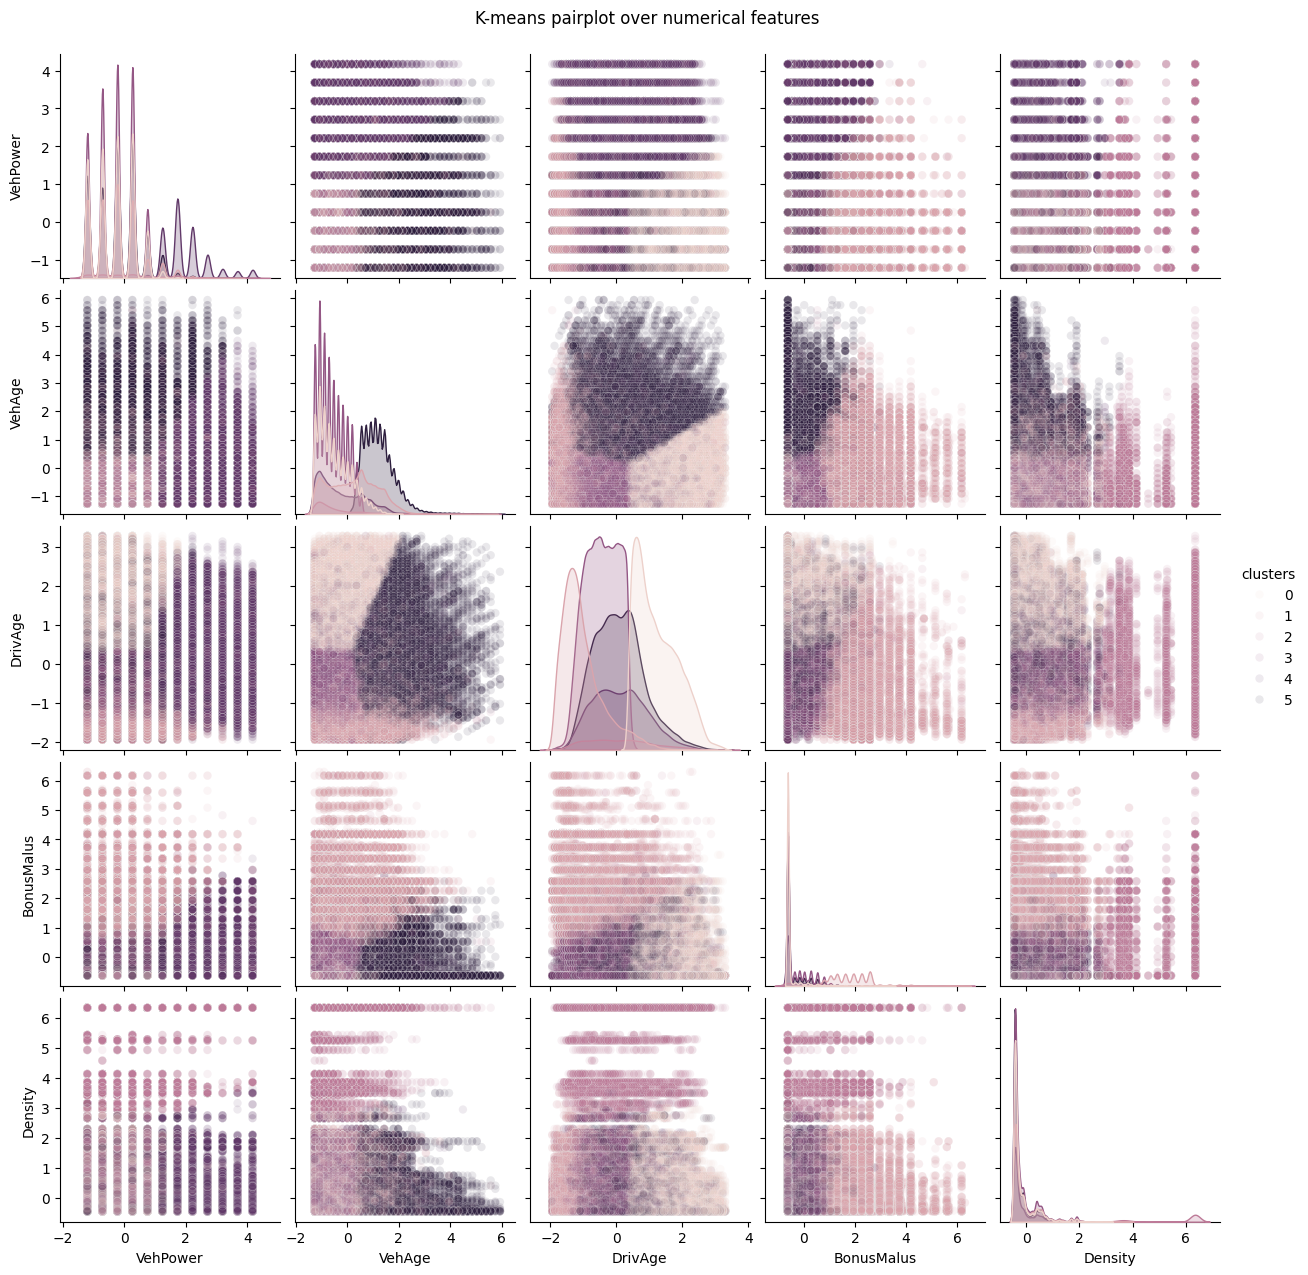

In [13]:
# Using n_clusters = 6
df['clusters'] = KMeans(n_clusters=6).fit_predict(df)
pairPlot = sns.pairplot(df, hue='clusters', plot_kws={'alpha': 0.1})
pairPlot.figure.suptitle("K-means pairplot over numerical features", y=1.02)
df.drop(columns=['clusters'], inplace=True)
